In [5]:
# %% load environment
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path
from torch.utils.data import DataLoader

join = os.path.join
import torch
from segment_anything import sam_model_registry
from skimage import io, transform
import torch.nn.functional as F

from monai.metrics import DiceMetric


from utils_segment import MedSAMMRIDataset, ComposeSampleTransforms, EnsureImageChannels, ResizeSample, medsam_inference_single, medsam_inference_batch



In [6]:
root="/home/jovyan/thesis_project"

device = "cuda:1"
ckpt = root + "/MedSAM/work_dir/MedSAM/medsam_vit_b.pth"  
model = sam_model_registry["vit_b"](checkpoint=ckpt).to(device).eval()

In [7]:
data_path = root + "/datasets/prep_datasets" + "/MnM_splits/vendor_split_ed_es/Philips"


medsam_model_transform = ComposeSampleTransforms([
    EnsureImageChannels(3),
    ResizeSample((1024, 1024)),
])


dataset= MedSAMMRIDataset(root= data_path,
                           slice_strategy="middle",
                           transform=medsam_model_transform)


data_loader= DataLoader(dataset, batch_size=4, shuffle=False, num_workers=0)

In [8]:
print(len(dataset))

250


In [10]:
batch=next(iter(data_loader))

print(batch.keys())

dict_keys(['image', 'label', 'path', 'gt_path', 'mask', 'bbox', 'original_size', 'resized_size'])


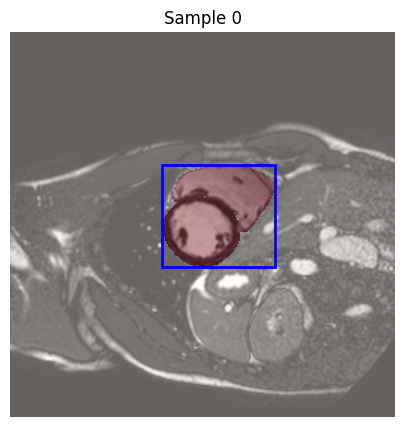

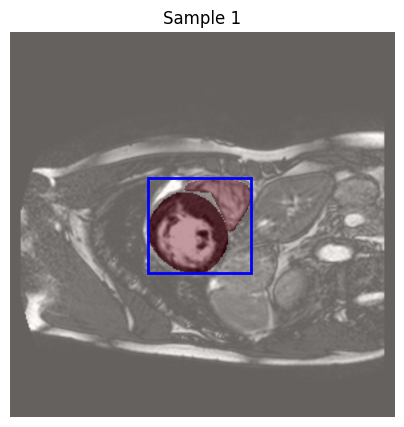

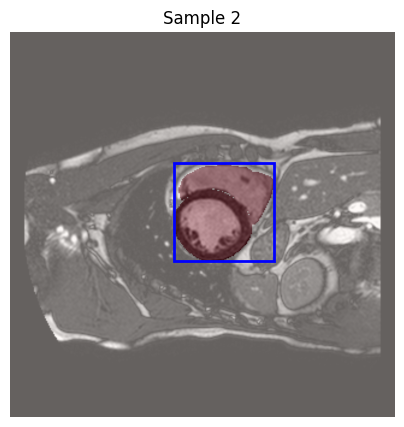

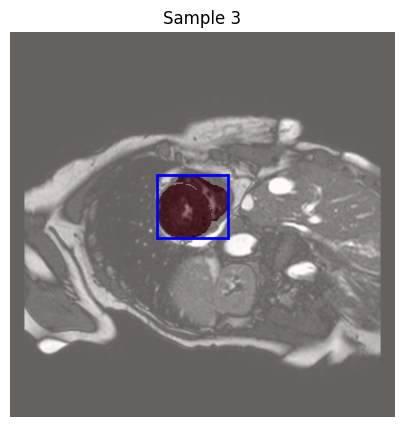

In [7]:
def show_batch(batch, n=4):
    images = batch["image"]
    masks = batch["mask"]
    bboxes = batch["bbox"]

    for i in range(min(n, images.shape[0])):
        img = images[i].permute(1, 2, 0).cpu().numpy()  # [H, W, C]
        mask = masks[i][0].cpu().numpy()               # [H, W]
        bbox = bboxes[i].cpu().numpy()

        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

        # show image (grayscale or RGB)
        if img.shape[-1] == 1:
            ax.imshow(img.squeeze(), cmap="gray")
        else:
            ax.imshow(img)

        # overlay mask
        ax.imshow(mask, alpha=0.4, cmap="Reds")

        # draw bbox
        x0, y0, x1, y1 = bbox
        rect = plt.Rectangle(
            (x0, y0),
            x1 - x0,
            y1 - y0,
            edgecolor="blue",
            facecolor="none",
            linewidth=2,
        )
        ax.add_patch(rect)

        ax.set_title(f"Sample {i}")
        ax.axis("off")

        plt.show()
        
show_batch(batch)

In [20]:
batch_dice_scores=[]

dice_metric = DiceMetric(
    include_background=False,   # usually better for medical tasks
    reduction="mean"
)

with torch.no_grad():
    for batch in data_loader:
        
        images = batch["image"].to(device)   # [B, 3, 1024, 1024]
        boxes = batch["bbox"].to(device)     # [B, 4]
        masks=batch["mask"].to(device)       # [B, 3, 1024, 1024]
    
        img_embed = model.image_encoder(images)   # [B, 256, 64, 64]

        pred_mask = medsam_inference_batch(
            medsam_model=model,
            img_embed=img_embed,
            box_1024=boxes,
            H=images.shape[-2],
            W=images.shape[-1],
        )

        dice = dice_metric(
            y_pred=pred_mask,   # [B, 1, H, W]
            y=masks             # [B, 1, H, W]
            )
        
        batch_dice_scores.append(dice.mean().item())

print(batch_dice_scores)

[0.7890114784240723, 0.6658331751823425, 0.6162645816802979, 0.5612295866012573, 0.6834874153137207, 0.7719822525978088, 0.6101595163345337, 0.8003075122833252, 0.7480331659317017, 0.6168381571769714, 0.7916415333747864, 0.7854100465774536, 0.6312756538391113, 0.658206045627594, 0.7757445573806763, 0.7359543442726135, 0.8447636365890503, 0.6431248188018799, 0.7197924852371216, 0.8242560625076294, 0.5695918798446655, 0.6563599109649658, 0.6231425404548645, 0.6644559502601624, 0.717524528503418, 0.7609023451805115, 0.6863911151885986, 0.5983803272247314, 0.6517072319984436, 0.6747149229049683, 0.8144897818565369, 0.7212461829185486, 0.8158818483352661, 0.7433868050575256, 0.7857944369316101, 0.7021188735961914, 0.684442400932312, 0.7709323763847351, 0.7277632355690002, 0.7817908525466919, 0.6121069192886353, 0.6170002222061157, 0.8044219613075256, 0.8811160326004028, 0.7162970900535583, 0.6480967402458191, 0.7625842094421387, 0.7090607285499573, 0.6298582553863525, 0.7084817886352539, 0.

In [22]:
print(sum(batch_dice_scores)/len(batch_dice_scores))

0.7203908505893889
